<a href="https://colab.research.google.com/github/viplove21r/Job-Analysis-2026/blob/main/Skills_Trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Libraries and Data**

In [18]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Group the Skills by Month

In [19]:
## Skill count per month for data analysts
df_india_da = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

df_india_da['job_posted_month_no'] = df_india_da['job_posted_date'].dt.month

# Explode job_skills column
df_india_da_explode = df_india_da.explode('job_skills')



## Skill count per month for Machine Learning Engineer
df_india_ml = df[(df['job_title'] == 'Machine Learning Engineer') & (df['job_country'] == 'India')].copy()

df_india_ml['job_posted_month_no'] = df_india_ml['job_posted_date'].dt.month

# Explode job_skills column
df_india_ml_explode = df_india_ml.explode('job_skills')

Creating a pivot table

In [20]:
# Group by month and job_skills
df_india_da_pivot = df_india_da_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

df_india_ml_pivot = df_india_ml_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

Sort columns by count and change month numbers to names

In [21]:
# sorts by count for da
df_india_da_pivot.loc['Total'] = df_india_da_pivot.sum()
df_india_da_pivot = df_india_da_pivot[df_india_da_pivot.loc['Total'].sort_values(ascending=False).index]
df_india_da_pivot = df_india_da_pivot.drop('Total')

# sorts by count fo ml
df_india_ml_pivot.loc['Total'] = df_india_ml_pivot.sum()
df_india_ml_pivot = df_india_ml_pivot[df_india_ml_pivot.loc['Total'].sort_values(ascending=False).index]
df_india_ml_pivot = df_india_ml_pivot.drop('Total')



Plotting the Monthly Skill Counts

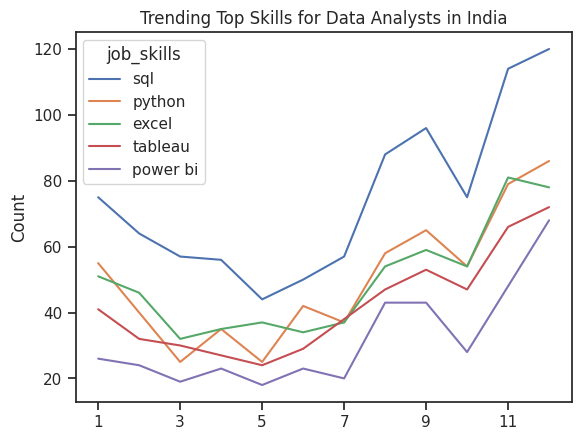

In [22]:
df_india_da_pivot.iloc[:, :5].plot(kind='line')

plt.title('Trending Top Skills for Data Analysts in India')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

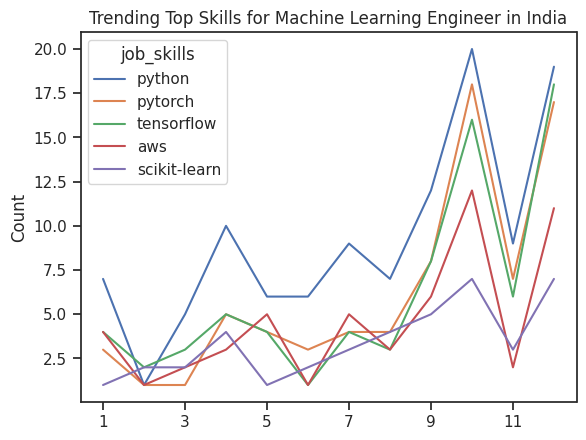

In [23]:
df_india_ml_pivot.iloc[:, :5].plot(kind='line')

plt.title('Trending Top Skills for Machine Learning Engineer in India')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

Calculating Percentage of Total Jobs

In [24]:
# Get monthly totals
DA_totals = df_india_da.groupby('job_posted_month_no').size()

ML_totals = df_india_ml.groupby('job_posted_month_no').size()

In [25]:
# divide first 12 rows of df_DA_pivot by DA_totals
df_DA_india_percent = df_india_da_pivot.iloc[:12].div(DA_totals/100, axis=0)

# changes month number to month name
df_DA_india_percent = df_DA_india_percent.reset_index()
df_DA_india_percent['job_posted_month'] = df_DA_india_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_india_percent = df_DA_india_percent.set_index('job_posted_month')
df_DA_india_percent = df_DA_india_percent.drop(columns='job_posted_month_no')

df_DA_india_percent

job_skills,sql,python,excel,tableau,power bi,sas,r,aws,azure,javascript,...,react.js,sqlite,suse,swift,tidyr,unify,vb.net,watson,webex,wire
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,52.083333,38.194444,35.416667,28.472222,18.055556,25.000000,15.972222,4.166667,3.472222,7.638889,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.694444,0.000000
Feb,54.237288,33.898305,38.983051,27.118644,20.338983,11.864407,19.491525,5.084746,5.932203,6.779661,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.847458,0.000000,0.000000
Mar,58.762887,25.773196,32.989691,30.927835,19.587629,10.309278,9.278351,7.216495,6.185567,3.092784,...,0.000000,0.000000,1.030928,1.030928,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Apr,56.565657,35.353535,35.353535,27.272727,23.232323,24.242424,16.161616,4.040404,8.080808,7.070707,...,1.010101,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
May,68.750000,39.062500,57.812500,37.500000,28.125000,15.625000,14.062500,6.250000,14.062500,4.687500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Jun,53.763441,45.161290,36.559140,31.182796,24.731183,30.107527,24.731183,10.752688,9.677419,5.376344,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Jul,61.956522,40.217391,40.217391,41.304348,21.739130,21.739130,25.000000,5.434783,8.695652,5.434783,...,0.000000,0.000000,0.000000,0.000000,1.086957,0.00000,0.000000,0.000000,0.000000,0.000000
Aug,62.411348,41.134752,38.297872,33.333333,30.496454,17.021277,19.858156,14.184397,7.801418,4.964539,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Sep,57.831325,39.156627,35.542169,31.927711,25.903614,15.662651,16.265060,7.228916,3.012048,8.433735,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.60241,0.000000,0.000000,0.000000,0.000000


In [26]:
# divide first 12 rows of df_ML_pivot by ML_totals
df_ML_india_percent = df_india_ml_pivot.iloc[:12].div(ML_totals/100, axis=0)

# changes month number to month name
df_ML_india_percent = df_ML_india_percent.reset_index()
df_ML_india_percent['job_posted_month'] = df_ML_india_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_ML_india_percent = df_ML_india_percent.set_index('job_posted_month')
df_ML_india_percent = df_ML_india_percent.drop(columns='job_posted_month_no')

df_ML_india_percent

job_skills,python,pytorch,tensorflow,aws,scikit-learn,sql,azure,spark,java,keras,...,matlab,node.js,sap,redis,powerpoint,shell,spring,theano,typescript,unix
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,100.000000,42.857143,57.142857,57.142857,14.285714,28.571429,57.142857,14.285714,14.285714,28.571429,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Feb,33.333333,33.333333,66.666667,33.333333,66.666667,33.333333,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Mar,83.333333,16.666667,50.000000,33.333333,33.333333,33.333333,16.666667,50.000000,50.000000,50.000000,...,0.000000,16.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Apr,90.909091,45.454545,45.454545,27.272727,36.363636,36.363636,27.272727,27.272727,36.363636,18.181818,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
May,85.714286,57.142857,57.142857,71.428571,14.285714,42.857143,28.571429,28.571429,42.857143,14.285714,...,0.000000,0.000000,14.285714,0.000000,0.000000,0.000000,0.000000,0.0,14.285714,0.000000
Jun,100.000000,50.000000,16.666667,16.666667,33.333333,33.333333,0.000000,33.333333,16.666667,16.666667,...,16.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Jul,90.000000,40.000000,40.000000,50.000000,30.000000,40.000000,20.000000,30.000000,20.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Aug,100.000000,57.142857,42.857143,42.857143,57.142857,42.857143,42.857143,28.571429,42.857143,57.142857,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Sep,80.000000,53.333333,53.333333,40.000000,33.333333,26.666667,20.000000,33.333333,26.666667,33.333333,...,0.000000,0.000000,0.000000,0.000000,6.666667,6.666667,6.666667,0.0,0.000000,6.666667


PlotTING Monthly Skill Demand

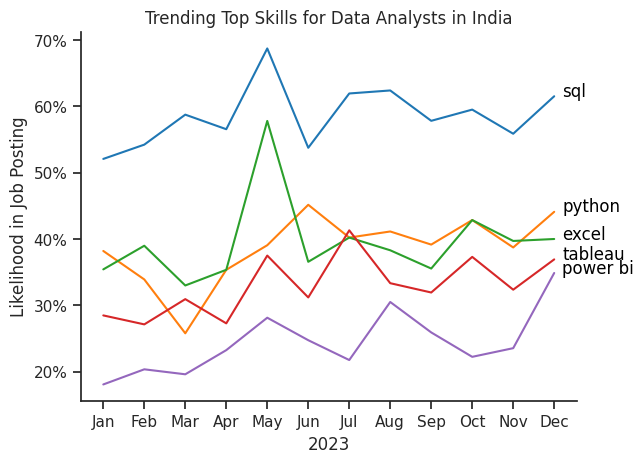

In [27]:
from matplotlib.ticker import PercentFormatter

df_plot = df_DA_india_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() # remove top and right spines

plt.title('Trending Top Skills for Data Analysts in India')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')

plt.show()

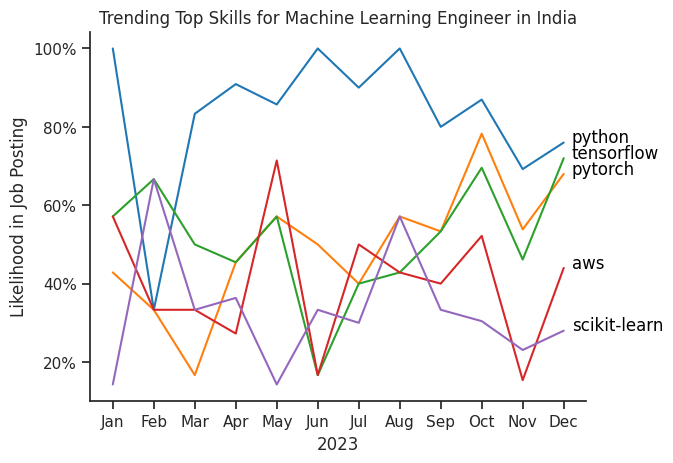

In [28]:
from matplotlib.ticker import PercentFormatter

df_plot = df_ML_india_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() # remove top and right spines

plt.title('Trending Top Skills for Machine Learning Engineer in India')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')

plt.show()